In [13]:
from google.colab import files

# Esto abrirá el selector de archivos
uploaded = files.upload()

# Una vez cargado, puedes verificar el nombre del archivo
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving MATAMOROS.csv to MATAMOROS.csv
User uploaded file "MATAMOROS.csv" with length 5474 bytes


In [14]:
import pandas as pd
import numpy as np

# 1. Cargar los datos
#df = pd.read_csv('TAMPICO.csv')
#df = pd.read_csv('HOUSTON.csv')
#df = pd.read_csv('MIAMI.csv')
df = pd.read_csv('MATAMOROS.csv')

series = df['temperature'].values  # Obtenemos el vector 1D

# 2. Definir los puntos de corte exactos (N=324)
# Entrenamiento (70%): 227 datos
# Validación (20%):    65 datos
# Prueba (10%):        32 datos
n_train = 227
n_val = 65
n_test = 32

# 3. Creación de los conjuntos 1D
# Para estos modelos, a veces el conjunto de 'entrenamiento'
# para el pronóstico final es la unión de (Train + Val)
train = series[:n_train]
val = series[n_train:n_train + n_val]
test = series[n_train + n_val:]

# 4. Verificación de integridad para tu manuscrito
print(f"--- Partición de Datos (1D) ---")
print(f"Total datos:        {len(series)}")
print(f"Train (0 a 226):    {len(train)} meses")
print(f"Val   (227 a 291):  {len(val)} meses")
print(f"Test  (292 a 323):  {len(test)} meses")

# Guardamos una referencia para el MASE (Error del modelo ingenuo en entrenamiento)
# Se calcula sobre el set de entrenamiento original
naive_mae_train = np.mean(np.abs(np.diff(train)))
print(f"Factor Naive MAE (para MASE): {naive_mae_train:.4f}")

--- Partición de Datos (1D) ---
Total datos:        324
Train (0 a 226):    227 meses
Val   (227 a 291):  65 meses
Test  (292 a 323):  32 meses
Factor Naive MAE (para MASE): 2.4500


In [15]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

def calc_smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error (%)"""
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

def calc_da(y_true, y_pred):
    """Directional Accuracy (%)"""
    # Compara si la dirección (subida/bajada) es la misma en ambos vectores
    y_true_diff = np.diff(y_true)
    y_pred_diff = np.diff(y_pred)
    return 100 * np.mean(np.sign(y_true_diff) == np.sign(y_pred_diff))

def calc_mase(y_true, y_pred, y_train):
    """Mean Absolute Scaled Error"""
    # Calcula el error del modelo ingenuo en el conjunto de entrenamiento
    n = len(y_train)
    d = np.abs(np.diff(y_train)).sum() / (n - 1)

    # Si d es 0 (serie constante), evitamos división por cero
    if d == 0: return np.nan

    mae_model = mean_absolute_error(y_true, y_pred)
    return mae_model / d

Iniciando búsqueda de hiperparámetros SSA (L y r) en Validación...

--- SINTONIZACIÓN COMPLETADA ---
Mejor Ventana (L): 60
Mejor Componente (r): 6
RMSE (Validación): 1.7015

Calculando pronóstico definitivo sobre el conjunto de PRUEBA...

=== RESULTADOS FINALES SSA (Conjunto Test) ===
RMSE:  1.5899
SMAPE: 5.04%
DA:    80.65%
MASE:  0.4895


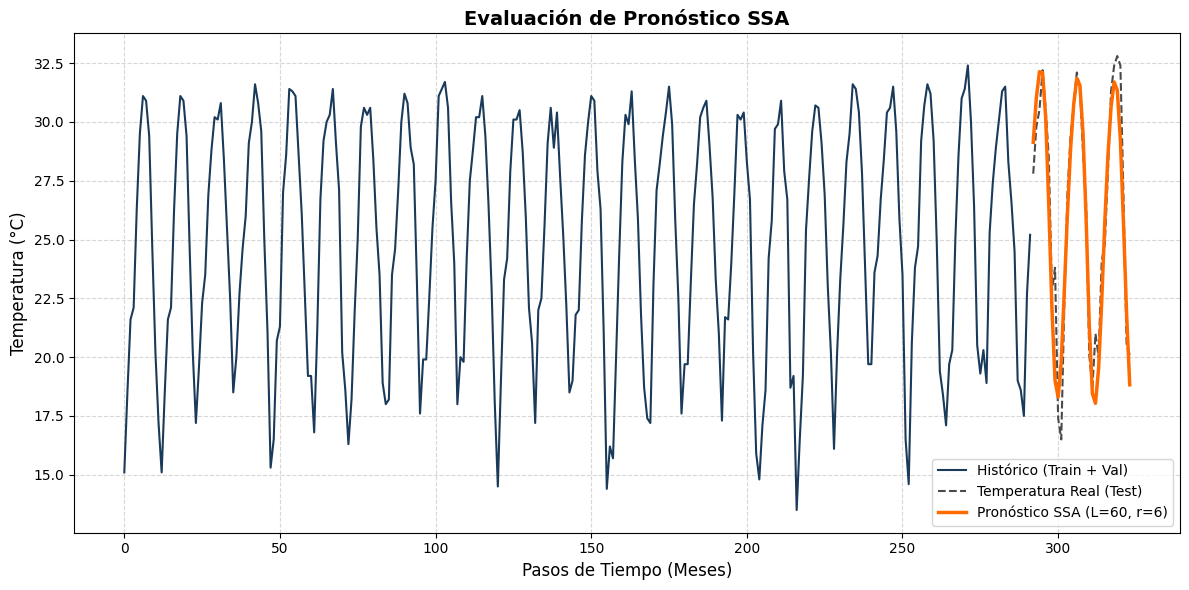


[ÉXITO] Archivos guardados: 'ssa_puro_test_forecast.png' y 'MATAMOROS-resultados_ssa_puro_test.csv'.


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import svd
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =====================================================================
# 1. FUNCIÓN SSA (Proporcionada por el Autor)
# =====================================================================
def ssa_lrr_forecast(series, L, r, n_forecast):
    """
    Pronóstico SSA usando Relaciones de Recurrencia Lineal (LRR).
    """
    N = len(series)
    # 1. Embedding: Crear la matriz de trayectoria
    K = N - L + 1
    X = np.column_stack([series[i:i+L] for i in range(K)])

    # 2. SVD: Descomposición en valores singulares
    U, s, Vh = svd(X)
    Ur = U[:, :r] # Tomamos solo los r componentes principales

    # 3. Obtener coeficientes de la Relación de Recurrencia Lineal (LRR)
    v2 = Ur[-1, :] # Última fila
    U_sub = Ur[:-1, :] # Todas las filas excepto la última

    # Coeficiente vertical de la proyección
    vertical_sq = np.sum(v2**2)
    if vertical_sq >= 1: # Evitar inestabilidad numérica
        return np.full(n_forecast, np.nan)

    # Vector de coeficientes R
    R = (1 / (1 - vertical_sq)) * np.dot(U_sub, v2)
    R = R[::-1] # Invertimos para la aplicación directa del producto punto

    # 4. Pronóstico iterativo
    forecast = list(series)
    for _ in range(n_forecast):
        # Tomamos los últimos L-1 datos para predecir el siguiente
        next_val = np.dot(R, forecast[-(L-1):])
        forecast.append(next_val)

    return np.array(forecast[N:])

# =====================================================================
# 2. FUNCIONES DE MÉTRICAS Q1
# =====================================================================
def calc_smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

def calc_da(y_true, y_pred):
    y_true_diff = np.diff(y_true)
    y_pred_diff = np.diff(y_pred)
    if len(y_true_diff) == 0: return np.nan
    return 100 * np.mean(np.sign(y_true_diff) == np.sign(y_pred_diff))

def calc_mase(y_true, y_pred, y_train):
    n = len(y_train)
    d = np.abs(np.diff(y_train)).sum() / (n - 1)
    if d == 0: return np.nan
    mae_model = mean_absolute_error(y_true, y_pred)
    return mae_model / d

# =====================================================================
# FASE 1: SINTONIZACIÓN PURA (Búsqueda Exhaustiva de L y r en Validación)
# =====================================================================
n_train = len(train)
n_val = len(val)
best_rmse = float('inf')
best_L, best_r = 0, 0

print("Iniciando búsqueda de hiperparámetros SSA (L y r) en Validación...")

# L va desde la mitad de la serie hasta 12 (un ciclo anual)
for L in range(int(n_train/2), 12, -1):
    for r in range(L-1, 1, -1):

        preds_val = ssa_lrr_forecast(train, L, r, n_val)

        # Filtro de divergencia (inestabilidad numérica)
        if np.any(np.isnan(preds_val)) or np.max(np.abs(preds_val)) > 50:
            continue

        rmse_val = np.sqrt(mean_squared_error(val, preds_val))

        if rmse_val < best_rmse:
            best_rmse = rmse_val
            best_L = L
            best_r = r

print(f"\n--- SINTONIZACIÓN COMPLETADA ---")
print(f"Mejor Ventana (L): {best_L}")
print(f"Mejor Componente (r): {best_r}")
print(f"RMSE (Validación): {best_rmse:.4f}")

# =====================================================================
# FASE 2: EVALUACIÓN FINAL CÍEGA (Sobre conjunto de Prueba)
# =====================================================================
if best_L > 0:
    print("\nCalculando pronóstico definitivo sobre el conjunto de PRUEBA...")

    # Unimos Train y Val para darle al modelo toda la historia disponible antes del Test
    history = np.concatenate((train, val))
    n_test = len(test)

    # Pronóstico en el Test usando los hiperparámetros ganadores
    test_preds = ssa_lrr_forecast(history, best_L, best_r, n_test)

    # Cálculo de métricas finales
    final_rmse = np.sqrt(mean_squared_error(test, test_preds))
    final_smape = calc_smape(test, test_preds)
    final_da = calc_da(test, test_preds)
    #final_mase = calc_mase(test, test_preds, history)
    final_mase = calc_mase(test, test_preds, train)

    print("\n=== RESULTADOS FINALES SSA (Conjunto Test) ===")
    print(f"RMSE:  {final_rmse:.4f}")
    print(f"SMAPE: {final_smape:.2f}%")
    print(f"DA:    {final_da:.2f}%")
    print(f"MASE:  {final_mase:.4f}")
    print("==============================================")

    # =====================================================================
    # FASE 3: EXPORTACIÓN Y GRÁFICA DE LA PRUEBA FINAL
    # =====================================================================
    plt.figure(figsize=(12, 6))

    time_history = np.arange(len(history))
    time_test = np.arange(len(history), len(history) + n_test)

    plt.plot(time_history, history, label='Histórico (Train + Val)', color='#1A3A5A', linewidth=1.5)
    plt.plot(time_test, test, label='Temperatura Real (Test)', color='#4A4A4A', linestyle='--', linewidth=1.5)
    plt.plot(time_test, test_preds, label=f'Pronóstico SSA (L={best_L}, r={best_r})', color='#FF6B00', linewidth=2.5)

    plt.title('Evaluación de Pronóstico SSA', fontsize=14, fontweight='bold')
    plt.xlabel('Pasos de Tiempo (Meses)', fontsize=12)
    plt.ylabel('Temperatura (°C)', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    #plt.savefig('tampico-ssa_puro_test_forecast.png', dpi=300, bbox_inches='tight')
    #plt.savefig('HOUSTON-ssa_puro_test_forecast.png', dpi=300, bbox_inches='tight')
    #plt.savefig('MIAMI-ssa_puro_test_forecast.png', dpi=300, bbox_inches='tight')
    plt.savefig('MATAMOROS-ssa_puro_test_forecast.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Guardamos el CSV
    df_results = pd.DataFrame({
        'Paso_Tiempo': time_test,
        'Temp_Real_Test': test,
        'Pronostico_SSA': test_preds,
        'Error_Absoluto': np.abs(test - test_preds)
    })

    #csv_filename = 'TAMPICO-resultados_ssa_puro_test.csv'
    #csv_filename = 'HOUSTON-resultados_ssa_puro_test.csv'
    #csv_filename = 'MIAMI-resultados_ssa_puro_test.csv'
    csv_filename = 'MATAMOROS-resultados_ssa_puro_test.csv'
    df_results.to_csv(csv_filename, index=False)
    print(f"\n[ÉXITO] Archivos guardados: 'ssa_puro_test_forecast.png' y '{csv_filename}'.")

else:
    print("ERROR: El modelo divergió en todos los hiperparámetros de validación.")

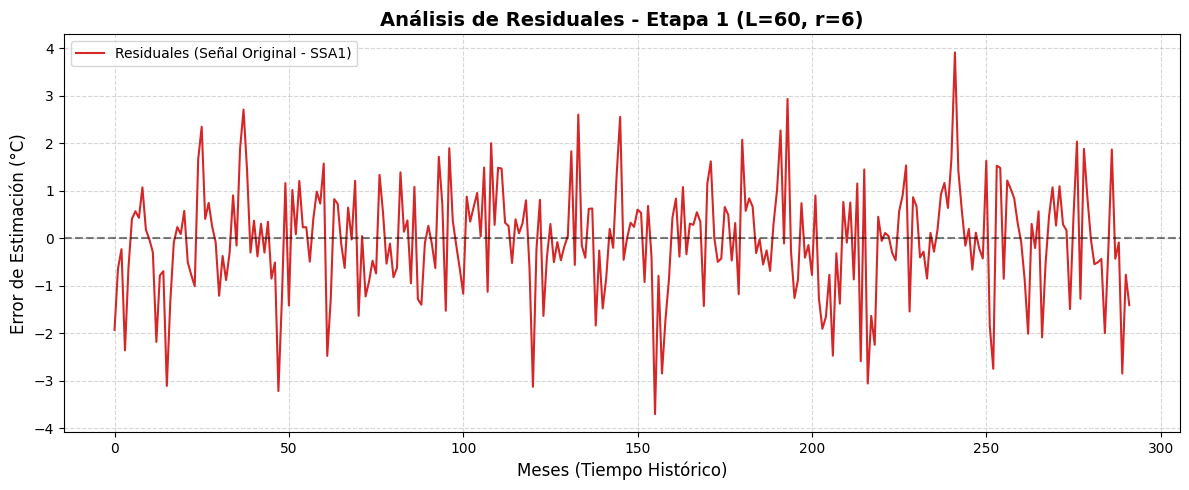

--- Análisis de Residuales ---
Media de los residuales: -0.0341
Desviación Estándar:     1.1527
Valor Máximo Residual:   3.9167


In [17]:
# =====================================================================
# FASE 4: OBTENCIÓN DE RESIDUALES (ASSAF - ETAPA 1)
# =====================================================================

def ssa_reconstruct(series, L, r):
    """
    Reconstrucción (Diagonal Averaging) para obtener la estimación in-sample.
    """
    N = len(series)
    K = N - L + 1
    # 1. Embedding
    X = np.column_stack([series[i:i+L] for i in range(K)])

    # 2. SVD
    U, s, Vh = svd(X)
    Ur = U[:, :r]

    # 3. Reconstrucción de la matriz de trayectoria proyectada
    X_hat = Ur @ Ur.T @ X

    # 4. Diagonal Averaging (L-reconstruction)
    g = np.zeros(N)
    for k in range(N):
        # Promediamos las diagonales inversas para volver al vector 1D
        vals = [X_hat[i, k-i] for i in range(L) if 0 <= k-i < K]
        g[k] = np.mean(vals)
    return g

# 1. Calculamos la "estimación" de la historia usando los parámetros óptimos (L=108, r=4)
reconstructed_signal = ssa_reconstruct(history, best_L, best_r)

# 2. Obtenemos los RESIDUALES (Original - Estimación SSA1)
# Esta es la señal que pasaremos a la Etapa 2 para buscar patrones ocultos
residuals = history - reconstructed_signal

# 3. Visualización de los Residuales
plt.figure(figsize=(12, 5))
plt.plot(residuals, color='#D62728', linewidth=1.5, label='Residuales (Señal Original - SSA1)')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

plt.title(f'Análisis de Residuales - Etapa 1 (L={best_L}, r={best_r})', fontsize=14, fontweight='bold')
plt.xlabel('Meses (Tiempo Histórico)', fontsize=12)
plt.ylabel('Error de Estimación (°C)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"--- Análisis de Residuales ---")
print(f"Media de los residuales: {np.mean(residuals):.4f}")
print(f"Desviación Estándar:     {np.std(residuals):.4f}")
print(f"Valor Máximo Residual:   {np.max(np.abs(residuals)):.4f}")

Calculando reconstrucción in-sample y extrayendo residuales...
RMSE Base en Validación a vencer: 1.7015
Iniciando búsqueda de hiperparámetros (L_sub y r_sub) para Residuales en Validación...

--- SINTONIZACIÓN ETAPA 2 COMPLETADA ---
Mejor Ventana Residual (L_sub): 31
Mejor Componente Residual (r_sub): 2
NUEVO RMSE Combinado (Validación): 1.6382

Calculando pronóstico definitivo ASSAF sobre el conjunto de PRUEBA...

=== RESULTADOS FINALES ASSAF (Conjunto Test) ===
RMSE:  1.6113
SMAPE: 5.05%
DA:    83.87%
MASE:  0.5019
Mejora respecto a SSA Puro: -0.0215 °C en RMSE


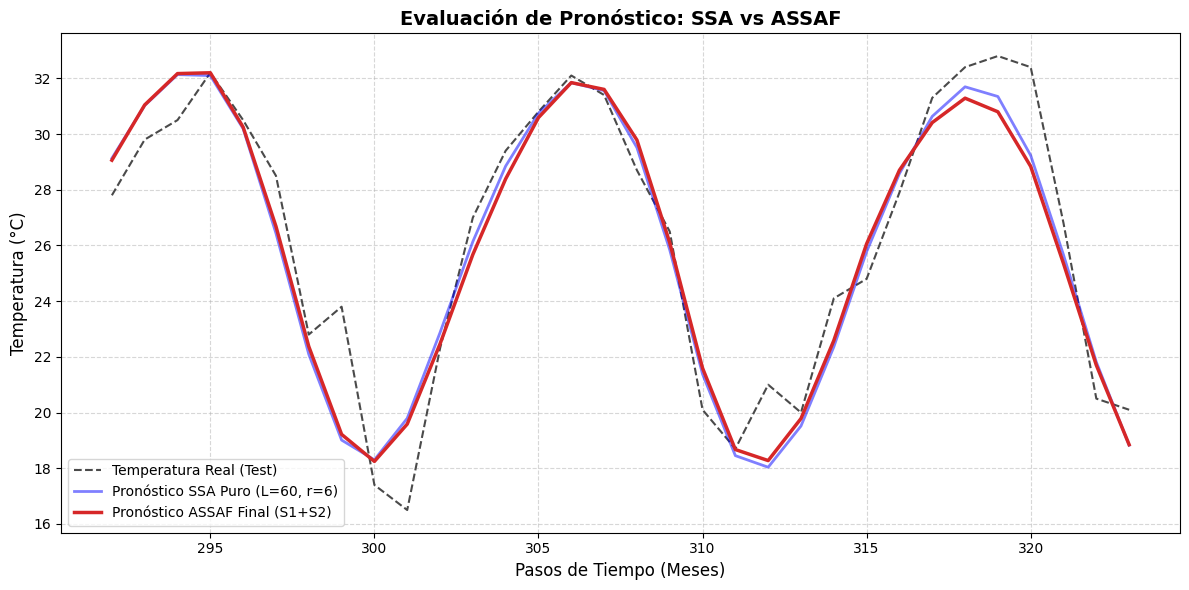


[ÉXITO] Archivo guardado: 'MATAMOROS-resultados_assaf_test.csv'.


In [19]:
# =====================================================================
# FASE 4: OBTENCIÓN DE RESIDUALES (ASSAF - ETAPA 1)
# =====================================================================

def ssa_reconstruct(series, L, r):
    """
    Reconstrucción (Diagonal Averaging) para obtener la estimación in-sample.
    Permite calcular el residuo histórico.
    """
    N = len(series)
    K = N - L + 1
    # 1. Embedding: Matriz de trayectoria
    X = np.column_stack([series[i:i+L] for i in range(K)])

    # 2. SVD
    U, s, Vh = svd(X)
    Ur = U[:, :r]

    # 3. Proyectar y reconstruir la matriz
    X_hat = Ur @ Ur.T @ X

    # 4. Diagonal Averaging para volver a serie temporal 1D
    g = np.zeros(N)
    for k in range(N):
        # Promedio de las diagonales inversas
        vals = [X_hat[i, k-i] for i in range(L) if 0 <= k-i < K]
        g[k] = np.mean(vals)
    return g

print("Calculando reconstrucción in-sample y extrayendo residuales...")
# 1. Generamos la 'estimación' de toda la historia (Train + Val)
reconstructed_signal = ssa_reconstruct(history, best_L, best_r)

# 2. Calculamos los RESIDUALES (Original - Reconstruida)
residuals = history - reconstructed_signal

# =====================================================================
# FASE 5: SINTONIZACIÓN AUTOMÁTICA ETAPA 2 (RESIDUALES)
# =====================================================================

# 1. Separar los residuales en Entrenamiento y Validación (misma proporción)
res_train = residuals[:n_train]
res_val = residuals[n_train:n_train + n_val]

# 2. Obtener la predicción base del SSA1 en Validación
preds_ssa1_val = ssa_lrr_forecast(train, best_L, best_r, n_val)

# INICIALIZAMOS best_rmse_assaf CON EL ERROR BASE PARA GARANTIZAR MEJORA
best_rmse_assaf = np.sqrt(mean_squared_error(val, preds_ssa1_val))
mejoro_en_validacion = False

best_L_sub, best_r_sub = 0, 0

print(f"RMSE Base en Validación a vencer: {best_rmse_assaf:.4f}")
print("Iniciando búsqueda de hiperparámetros (L_sub y r_sub) para Residuales en Validación...")

# Búsqueda de L_sub (desde la mitad del train de residuales hasta 6 meses)
for L_sub in range(int(n_train/2), 6, -1):
    #for r_sub in range(L_sub-1, 1, -1):
    for r_sub in range(1, 3):

        # Pronosticamos el residual en validación
        preds_res_val = ssa_lrr_forecast(res_train, L_sub, r_sub, n_val)

        # Filtro de divergencia (inestabilidad numérica del LRR)
        #if np.any(np.isnan(preds_res_val)) or np.max(np.abs(preds_res_val)) > 50:
        if np.any(np.isnan(preds_res_val)) or np.max(np.abs(preds_res_val)) > 4.0:

            continue

        # EVALUACIÓN COMBINADA: Estimación Original + Estimación del Residual
        combined_val_preds = preds_ssa1_val + preds_res_val
        rmse_comb = np.sqrt(mean_squared_error(val, combined_val_preds))

        if rmse_comb < best_rmse_assaf:
            best_rmse_assaf = rmse_comb
            best_L_sub = L_sub
            best_r_sub = r_sub
            mejoro_en_validacion = True

print(f"\n--- SINTONIZACIÓN ETAPA 2 COMPLETADA ---")
if mejoro_en_validacion:
    print(f"Mejor Ventana Residual (L_sub): {best_L_sub}")
    print(f"Mejor Componente Residual (r_sub): {best_r_sub}")
    print(f"NUEVO RMSE Combinado (Validación): {best_rmse_assaf:.4f}")
else:
    print("El modelo ASSAF determinó que los residuales son ruido blanco en validación.")

# =====================================================================
# FASE 6: EVALUACIÓN FINAL CÍEGA ASSAF (Sobre conjunto de Prueba)
# =====================================================================
if mejoro_en_validacion and best_L_sub > 0:
    print("\nCalculando pronóstico definitivo ASSAF sobre el conjunto de PRUEBA...")

    # 1. Pronóstico del error en el conjunto de Prueba
    test_preds_res = ssa_lrr_forecast(residuals, best_L_sub, best_r_sub, n_test)

    # 2. SUMA FINAL ASSAF (S1 + S2)
    assaf_final_preds = test_preds + test_preds_res

    # 3. Cálculo de métricas finales
    final_rmse_assaf = np.sqrt(mean_squared_error(test, assaf_final_preds))
    final_smape_assaf = calc_smape(test, assaf_final_preds)
    final_da_assaf = calc_da(test, assaf_final_preds)
    #final_mase_assaf = calc_mase(test, assaf_final_preds, history)
    final_mase_assaf = calc_mase(test, assaf_final_preds, train)

    print("\n=== RESULTADOS FINALES ASSAF (Conjunto Test) ===")
    print(f"RMSE:  {final_rmse_assaf:.4f}")
    print(f"SMAPE: {final_smape_assaf:.2f}%")
    print(f"DA:    {final_da_assaf:.2f}%")
    print(f"MASE:  {final_mase_assaf:.4f}")
    print("==============================================")
    print(f"Mejora respecto a SSA Puro: {final_rmse - final_rmse_assaf:.4f} °C en RMSE")

    # =====================================================================
    # FASE 7: EXPORTACIÓN Y GRÁFICA DE LA PRUEBA FINAL ASSAF
    # =====================================================================
    plt.figure(figsize=(12, 6))

    time_history = np.arange(len(history))
    time_test = np.arange(len(history), len(history) + n_test)

    plt.plot(time_test, test, label='Temperatura Real (Test)', color='#4A4A4A', linestyle='--', linewidth=1.5)
    plt.plot(time_test, test_preds, label=f'Pronóstico SSA Puro (L={best_L}, r={best_r})', color='blue', alpha=0.5, linewidth=2)
    plt.plot(time_test, assaf_final_preds, label=f'Pronóstico ASSAF Final (S1+S2)', color='#D62728', linewidth=2.5)

    plt.title('Evaluación de Pronóstico: SSA vs ASSAF', fontsize=14, fontweight='bold')
    plt.xlabel('Pasos de Tiempo (Meses)', fontsize=12)
    plt.ylabel('Temperatura (°C)', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    #plt.savefig('tampico-assaf_test_forecast.png', dpi=300, bbox_inches='tight')
    #plt.savefig('houston-assaf_test_forecast.png', dpi=300, bbox_inches='tight')
    #plt.savefig('miami-assaf_test_forecast.png', dpi=300, bbox_inches='tight')
    plt.savefig('matamoros-assaf_test_forecast.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Guardamos el CSV
    df_assaf_results = pd.DataFrame({
        'Paso_Tiempo': time_test,
        'Temp_Real_Test': test,
        'Pronostico_SSA_Puro': test_preds,
        'Pronostico_ASSAF': assaf_final_preds,
        'Error_Absoluto_ASSAF': np.abs(test - assaf_final_preds)
    })

    #csv_assaf_filename = 'TAMPICO-resultados_assaf_test.csv'
    #csv_assaf_filename = 'HOUSTON-resultados_assaf_test.csv'
    #csv_assaf_filename = 'MIAMI-resultados_assaf_test.csv'
    csv_assaf_filename = 'MATAMOROS-resultados_assaf_test.csv'
    df_assaf_results.to_csv(csv_assaf_filename, index=False)
    print(f"\n[ÉXITO] Archivo guardado: '{csv_assaf_filename}'.")

else:
    print("==============================================")
    print("INFO: El modelo ASSAF conservó el SSA original.")
    print("La suma de los residuales no aportó mejora en Validación.")
    print("El modelo es robusto y previno el sobreajuste (overfitting).")